<a href="https://colab.research.google.com/github/mokshManchandani/data-science/blob/deeplearning-pytorch-udemy/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ANN For regression

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-2ce0d24443bf>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


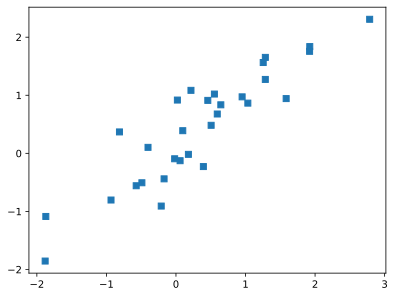

In [2]:
# Create Data
N = 30
x = torch.randn(N,1)
y = x + torch.randn(N,1) / 2


plt.plot(x,y,'s');

In [3]:
# build model
ANNReg = nn.Sequential(
  nn.Linear(1, 1),
  nn.ReLU(),
  nn.Linear(1,1)
)

ANNReg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [4]:
# learning rate
learning_rate = 0.05

# loss function

lossfunc = nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(ANNReg.parameters(), lr=learning_rate)

In [5]:
# training loop
numepochs = 500
lossi = torch.zeros(numepochs)

for epochi in range(numepochs):
  yHat = ANNReg(x)
  loss = lossfunc(yHat, y)
  lossi[epochi] = loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


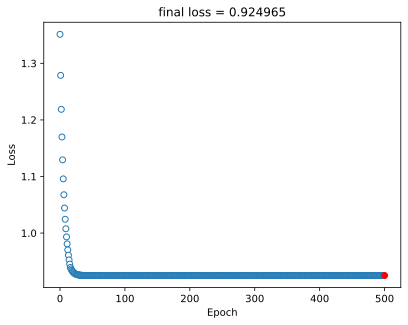

In [6]:
predictions = ANNReg(x)
testloss = (predictions - y).pow(2).mean()

plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
plt.plot(numepochs, testloss.detach().numpy(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('final loss = %g'%testloss.item())
plt.show();

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


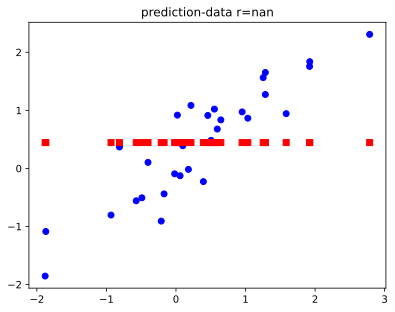

In [7]:
plt.plot(x, y, 'bo', label='real data')
plt.plot(x, predictions.detach(), 'rs', label='predictions')
plt.title(f'prediction-data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}');

Code challenge for the above.

In [19]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-19-2da2361c6caa>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [20]:
def create_data(N, m=1):
  x = torch.randn(N,1)
  y = m * x + torch.randn(N,1) / 2
  # plt.plot(x,y,'s');
  return x, y

In [21]:
def build_and_train_model(x, y, num_epochs, learning_rate, loss_func, optimizer_func):
# package the code of building and training the model into a function
  # build the model
  model = nn.Sequential(
    nn.Linear(1, 1),
    nn.ReLU(),
    nn.Linear(1,1)
  )


  # init the optimizer
  optimizer = optimizer_func(model.parameters(), lr=learning_rate)
  # track the stats
  lossi = torch.zeros(num_epochs)


  # train the model
  for epochi in range(num_epochs):
    yHat = model(x)
    loss = loss_func(yHat, y)
    lossi[epochi]= loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  predictions = model(x)
  # testloss = (predictions - y).pow(2).mean()

  # plt.figure(figsize=(10,4))
  # # show two plots on the same row
  # # show the loss over epochs
  # plt.subplot(1,2,1)
  # plt.plot(lossi.detach().numpy(),'o', markerfacecolor='w', linewidth=.1)
  # plt.xlabel('Epoch')
  # plt.ylabel('Loss')
  # plt.title('final loss = %g'%testloss.item())

  # # show the accuracy
  # plt.subplot(1,2,2)
  # plt.plot(x, y, 'bo', label='real data')
  # plt.plot(x, predictions.detach(), 'rs', label='predictions')
  # plt.title(f'prediction-data r={np.corrcoef(y.T, predictions.detach().T)[0,1]:.2f}');

  return lossi, predictions


In [22]:
# get the data
x, y = create_data(N = 50)

In [23]:
# train the model
lossi, predictions = build_and_train_model(x, y, num_epochs=500, learning_rate=0.05, loss_func = nn.MSELoss(), optimizer_func=torch.optim.SGD)

In [24]:
# create slopes from -2, +2 in 21 steps

slopes = torch.linspace(-2,2,21)
num_experiments = 50

results = np.zeros((len(slopes), num_experiments, 2))


for slopeidx, slope in enumerate(slopes):
  for experimenti in range(num_experiments):
    x, y = create_data(N = 50, m = slope)
    lossi, yHat = build_and_train_model(x, y, num_epochs=500, learning_rate=0.05, loss_func = nn.MSELoss(), optimizer_func=torch.optim.SGD)
    results[slopeidx, experimenti, 0] = lossi[-1].item()
    results[slopeidx, experimenti, 1] = np.corrcoef(y.T, yHat.detach().T)[0,1]

results.shape


/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


(21, 50, 2)

In [25]:
# reset nan-> 0
results[np.isnan(results)] = 0

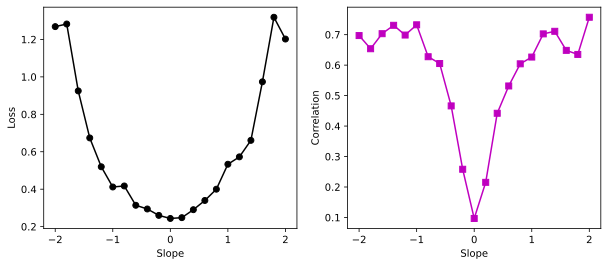

In [26]:
fix, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].plot(slopes, results[:,:,0].mean(axis=1), 'ko-')
ax[0].set_xlabel('Slope')
ax[0].set_ylabel('Loss')

ax[1].plot(slopes, results[:,:,1].mean(axis=1), 'ms-')
ax[1].set_xlabel('Slope')
ax[1].set_ylabel('Correlation')

plt.show()